# Claim 1 Evaluation and the Two Gates

Scores the trained model against the full baseline ladder on the 2025 frame, audits the
query machinery that produces those scores, and reports both pre-registered gates. The
decisive stratum fails, and most of this notebook is the work of making that failure
attributable rather than merely recorded.

Every number is read from an artifact committed under `results/model_evaluation_final_clean`
or `results/model_v1`. Nothing here trains, scores, or recomputes.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import claim1_eval
from src.model import query

## Configuration

Artifact locations and the orderings used for every table below. The scored arm is the
`clean_dim64_final` ensemble (64-dimension embedding table on plain SGD, refit on
2015-2024 with career pitcher-batters excluded from training) and the frame is 2025,
the sealed test season.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)

PHASE_E_DIR = REPO_ROOT / "results/model_evaluation_final_clean"
PHASE_C_DIR = REPO_ROOT / "results/baseline_ladder"
PHASE_D_DIR = REPO_ROOT / "results/model_v1"
PHASE_F_DIR = REPO_ROOT / "results/process_calibration_final_clean"

SCORED_ARM = "min_pa_sweep_clean_dim64_final"
EVAL_SEASON = 2025

LADDER_ORDER = ["no_info_league_average", "trailing_raw", "trailing_bucketed", "eb_bivariate",
                "eb_book_rho_reference", "gbm_outcome", "gbm_full", "model_v1"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load_e(name):
    """Read one committed Phase E artifact by filename."""
    return pd.read_csv(PHASE_E_DIR / name)


def load_json_e(name):
    """Read one committed Phase E JSON artifact by filename."""
    return json.loads((PHASE_E_DIR / name).read_text())


def load_f(name):
    """Read one committed Phase F artifact by filename."""
    return pd.read_csv(PHASE_F_DIR / name)


def load_json_f(name):
    """Read one committed Phase F summary by filename."""
    return json.loads((PHASE_F_DIR / name).read_text())


## The two gates as pre-registered

No numeric threshold was set in advance. An ordering claim holds only if the model beats
both the bivariate empirical-Bayes baseline and the gradient-boosting baseline on weighted rank correlation in the stratum claimed, by paired
difference with batter clustering and a 95 percent interval excluding zero. The RMSE gate is
set against the gradient-boosting baseline alone.

The platoon adoption rule is separate and stricter. It asks whether the model beats the
incumbent at predicting the platoon differential itself, not the two sides.

## The full ladder on the claim 1 metric

Every baseline rung plus the model, scored on the same frame against the same answer key.
RMSE is PA weighted and lower is better. No comparison is claimed from these absolute
numbers, because two models scored against the same noisy target cannot be separated that
way.

In [3]:
ladder = load_e(f"model_v1_claim1_scores_{SCORED_ARM}.csv")
ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)
ladder["stratum"] = pd.Categorical(ladder["stratum"], STRATUM_ORDER, ordered=True)
ladder.pivot_table(index="model", columns="stratum",
                   values="pa_weighted_rmse", observed=False).round(5)

/var/folders/pf/jgfmjd9j39z8dmn0hk1cgswh0000gn/T/ipykernel_85015/619744370.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)


stratum,low,medium,high,all
model,,,,
no_info_league_average,0.06348,0.05041,0.04595,0.05046
trailing_raw,0.09083,0.05891,0.04152,0.05710
trailing_bucketed,0.06364,0.05537,0.04151,0.04920
eb_bivariate,0.06195,0.04921,0.03875,0.04597
eb_book_rho_reference,0.06192,0.04938,0.03877,0.04601
gbm_outcome,0.06041,0.04899,0.03927,0.04582
gbm_full,0.06088,0.04789,0.03853,0.04530


## Skill against the no information reference

The same errors expressed as the share of between hitter talent variance each rung captures.
Negative means worse than predicting the league average for everybody.

In [4]:
ladder.pivot_table(index="model", columns="stratum",
                   values="skill_vs_no_info", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.0000,0.0000,0.0000,0.0000
trailing_raw,-3.0715,-1.2560,0.3905,-0.7081
trailing_bucketed,-0.0149,-0.7102,0.3913,0.1240
eb_bivariate,0.1397,0.1613,0.6139,0.4288
eb_book_rho_reference,0.1427,0.1392,0.6125,0.4253
gbm_outcome,0.2768,0.1904,0.5733,0.4424
gbm_full,0.2351,0.3344,0.6308,0.4888


## Rank correlation by rung and stratum

The ordering metric, weighted by the wOBA denominator. This is the column the ordering gate
is decided on.

In [5]:
ladder.pivot_table(index="model", columns="stratum",
                   values="rank_corr_weighted", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.0177,-0.0867,-0.0238,-0.0690
trailing_raw,0.0826,0.1707,0.4683,0.3626
trailing_bucketed,0.0426,0.1443,0.4684,0.3632
eb_bivariate,0.1290,0.2229,0.4819,0.4024
eb_book_rho_reference,0.1330,0.2200,0.4818,0.4017
gbm_outcome,0.0723,0.2339,0.4696,0.4012
gbm_full,0.1236,0.2795,0.4914,0.4206


## The same ladder against a second answer key

Everything above is scored against observed wOBA, which carries the batted ball luck the
model is not trying to predict. Rescoring against xwOBA asks whether the ranking survives an
answer key with less of that luck in it. The model's ordering advantage is larger here and
its level error is larger, which is the same level versus order split the paired gates
handle.

In [6]:
both_targets = load_e(f"model_v1_both_targets_{SCORED_ARM}.csv")
both_targets = both_targets[both_targets["stratum"] == "all"]
both_targets.pivot_table(index="model", columns="target",
                         values=["pa_weighted_rmse", "rank_corr_weighted"]).round(4)

pa_weighted_rmse         rank_corr_weighted        
target                                     woba   xwoba               woba   xwoba
model                                                                             
eb_bivariate                             0.0460  0.0385             0.4024  0.4867
eb_book_rho_reference                    0.0460  0.0386             0.4017  0.4838
gbm_full                                 0.0453  0.0377             0.4206  0.5164
gbm_outcome                              0.0458  0.0389             0.4012  0.4778
min_pa_sweep_clean_dim64_final           0.0452  0.0364             0.4704  0.5914
no_info_league_average                   0.0505  0.0452            -0.0690 -0.0945
trailing_bucketed                        0.0492  0.0419             0.3632  0.4402
trailing_raw                             0.0571  0.0510             0.3626  0.4381
trailing_xwoba                           0.0478  0.0386             0.4105  0.5372

## Noise floor share of squared error

The held out target is itself a small sample measurement, so errors add in quadrature and
every rung pays the same floor. In the low stratum the floor dominates, which is why real
differences compress into what reads as rounding.

In [7]:
floor = ladder[ladder["model"] == "no_info_league_average"].copy()
floor["floor_share_of_mse"] = floor["noise_floor"] ** 2 / floor["pa_weighted_rmse"] ** 2
floor.set_index("stratum")[["n_hitters", "pa_weighted_rmse", "noise_floor",
                            "model_rmse", "floor_share_of_mse"]].round(4)

,n_hitters,pa_weighted_rmse,noise_floor,model_rmse,floor_share_of_mse
stratum,,,,,
low,384,0.0635,0.0515,0.0371,0.6591
medium,280,0.0504,0.0424,0.0272,0.7088
high,493,0.0460,0.0334,0.0315,0.5294
all,1157,0.0505,0.0392,0.0318,0.6035


## The gate verdicts

The model against each of the two named opponents, paired and batter clustered. Positive
rank difference favours the model. A gate passes only when the interval excludes zero.

In [8]:
gates = load_e(f"model_v1_claim1_paired_{SCORED_ARM}.csv")
gates["stratum"] = pd.Categorical(gates["stratum"], STRATUM_ORDER, ordered=True)
gates.sort_values(["opponent", "stratum"])[
    ["opponent", "stratum", "n_hitters", "n_batters",
     "rank_a", "rank_b", "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_difference", "ci_low_rmse", "ci_high_rmse"]].round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rank_a,rank_b,rank_difference,ci_low_rank,ci_high_rank,rmse_difference,ci_low_rmse,ci_high_rmse
0,eb_bivariate,low,384,246,0.16032,0.12903,0.03130,-0.08522,0.15168,-0.00142,-0.00472,0.00198
1,eb_bivariate,medium,280,236,0.42347,0.22293,0.20055,0.06161,0.33432,-0.00366,-0.00623,-0.00114
2,eb_bivariate,high,493,321,0.50070,0.48192,0.01878,-0.04512,0.08067,0.00077,-0.00078,0.00229
3,eb_bivariate,all,1157,618,0.47040,0.40242,0.06797,0.01511,0.12515,-0.00073,-0.00206,0.00060
4,gbm_full,low,384,246,0.16032,0.12362,0.03671,-0.08048,0.15470,-0.00035,-0.00252,0.00181
5,gbm_full,medium,280,236,0.42347,0.27953,0.14394,0.01252,0.26711,-0.00234,-0.00447,-0.00020
6,gbm_full,high,493,321,0.50070,0.49141,0.00929,-0.04790,0.06698,0.00099,-0.00046,0.00243
7,gbm_full,all,1157,618,0.47040,0.42063,0.04977,0.01100,0.08948,-0.00007,-0.00106,0.00097


In [9]:
verdict = load_json_e(f"model_v1_claim1_verdict_{SCORED_ARM}.json")
print(json.dumps(verdict, indent=2)[:1200])

{
  "decisive_stratum": "low",
  "rmse_gate_vs_gbm_full": false,
  "ordering_gate_vs_both": false,
  "by_stratum": {
    "all": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": true,
      "n_comparisons": 2
    },
    "high": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "low": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "medium": {
      "rmse_gate_vs_gbm_full": true,
      "ordering_gate_vs_both": true,
      "n_comparisons": 2
    }
  },
  "debiased_mean_excess_removed": 0.00458661921470575,
  "debiased_rmse_difference": {
    "low": {
      "rmse_difference": 0.00034988641854778735,
      "ci_low": -0.00225658394371987,
      "ci_high": 0.0029148412566603445
    },
    "medium": {
      "rmse_difference": -0.0021768739345878266,
      "ci_low": -0.004303285787873857,
      "ci_high": 4.978565665599697e-05
    },
    "high":

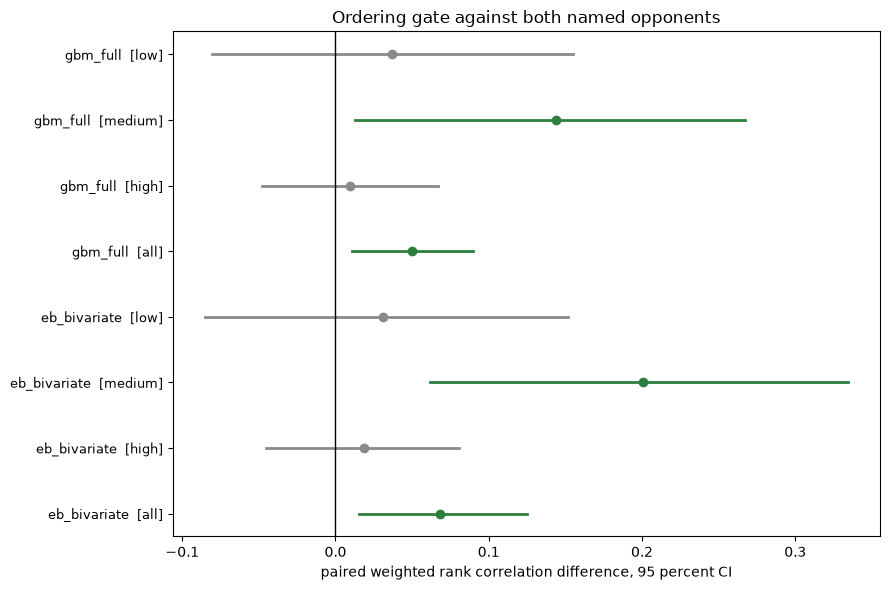

In [10]:
PASS_COLOR = "#2d7f3e"
FAIL_COLOR = "#8a8a8a"

plotted = gates.sort_values(["opponent", "stratum"], ascending=[True, False]).reset_index(drop=True)
figure, axis = plt.subplots(figsize=(9, 6))
for position, row in plotted.iterrows():
    excludes_zero = row["ci_low_rank"] > 0
    color = PASS_COLOR if excludes_zero else FAIL_COLOR
    axis.plot([row["ci_low_rank"], row["ci_high_rank"]], [position, position], color=color, lw=2)
    axis.plot(row["rank_difference"], position, "o", color=color, ms=6)
axis.axvline(0, color="black", lw=1)
axis.set_yticks(range(len(plotted)))
axis.set_yticklabels([f"{row.opponent}  [{row.stratum}]" for row in plotted.itertuples()],
                     fontsize=9)
axis.set_xlabel("paired weighted rank correlation difference, 95 percent CI")
axis.set_title("Ordering gate against both named opponents")
figure.tight_layout()
plt.show()

## Why the low stratum result is underpowered rather than absent

The model leads the gradient-boosting baseline on weighted rank in the low stratum by a margin larger than most
published effects, and the interval still spans zero. This restates the gap as the number of
batters that would be needed to resolve it.

In [11]:
power = load_e(f"model_v1_power_restatement_{SCORED_ARM}.csv")
power.set_index("stratum").round(4)

,n_batters,rank_difference,se_rank,z,batters_multiplier,batters_needed
stratum,,,,,,
low,246,0.0367,0.0600,0.6119,20.9658,5158
medium,236,0.1439,0.0649,2.2163,1.5978,377
high,321,0.0093,0.0293,0.3169,78.1315,25080
all,618,0.0498,0.0200,2.4857,1.2703,785


## Noise floor deconvolution

The same head to head with the target noise removed from both sides, so the comparison is
between the models rather than between two measurements of a noisy answer key.

In [12]:
debiased = load_e(f"model_v1_claim1_debiased_{SCORED_ARM}.csv")
debiased["stratum"] = pd.Categorical(debiased["stratum"], STRATUM_ORDER, ordered=True)
debiased.sort_values(["opponent", "stratum"]).round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rmse_a,rmse_b,rmse_difference,ci_low,ci_high,favours_a_share
0,gbm_full,low,384,246,0.06123,0.06088,0.00035,-0.00226,0.00291,0.3915
1,gbm_full,medium,280,236,0.04571,0.04789,-0.00218,-0.00430,0.00005,0.9710
2,gbm_full,high,493,321,0.03869,0.03853,0.00016,-0.00121,0.00151,0.3980
3,gbm_full,all,1157,618,0.04501,0.04530,-0.00030,-0.00132,0.00077,0.7200


In [13]:
achievable = load_e(f"model_v1_achievable_floor_{SCORED_ARM}.csv")
achievable.set_index("stratum").round(5)

,n_hitters,achievable_floor,xwoba_bias
stratum,,,
low,384,0.03613,0.00214
medium,280,0.03005,0.00058
high,493,0.02414,0.00433
all,1157,0.02792,0.00316


## The verdict across the censoring sweep

Every headline is reported across a three times swing in how much of the eval population the
PA floor removes. The verdict does not depend on the filter, and in the low stratum the gap
grows as the floor rises.

In [14]:
sweep = load_e("min_pa_sweep_b_min_pa_sweep.csv")
sweep["stratum"] = pd.Categorical(sweep["stratum"], STRATUM_ORDER, ordered=True)
sweep.sort_values(["opponent", "stratum", "min_eval_pa"])[
    ["min_eval_pa", "opponent", "stratum", "n_hitters", "n_batters",
     "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_favours_model_v1", "rank_favours_model_v1"]].round(5).reset_index(drop=True)

,min_eval_pa,opponent,stratum,n_hitters,n_batters,rank_difference,ci_low_rank,ci_high_rank,rmse_favours_model_v1,rank_favours_model_v1
0,10,eb_bivariate,low,384,246,0.03130,-0.08522,0.15168,False,False
1,25,eb_bivariate,low,299,208,0.01978,-0.10460,0.15015,False,False
2,50,eb_bivariate,low,211,163,0.00877,-0.13526,0.15625,False,False
3,10,eb_bivariate,medium,280,236,0.20055,0.06161,0.33432,True,True
4,25,eb_bivariate,medium,245,211,0.19989,0.05480,0.33971,True,True
5,50,eb_bivariate,medium,210,181,0.19457,0.04889,0.33255,True,True
6,10,eb_bivariate,high,493,321,0.01878,-0.04512,0.08067,False,False
7,25,eb_bivariate,high,473,309,0.01935,-0.03973,0.08273,False,False
8,50,eb_bivariate,high,437,295,0.01812,-0.04455,0.07983,False,False
9,10,eb_bivariate,all,1157,618,0.06797,0.01511,0.12515,False,True


## The platoon adoption rule

The stricter claim, scored on the platoon differential itself rather than the two sides. No
stratum's paired interval excludes zero on rank, so the rule is not met on 2025.

In [15]:
platoon_scores = load_e("platoon_scores.csv")
platoon_scores["stratum"] = pd.Categorical(platoon_scores["stratum"], STRATUM_ORDER, ordered=True)
platoon_scores.sort_values(["stratum", "model"]).round(5).reset_index(drop=True)

,stratum,model,n_hitters,weight,mean_obs,mean_pred,sd_obs,sd_pred,rmse,rank_corr_weighted
0,low,delta_pred,204,17320.49099,-0.00971,-0.00744,0.07826,0.02532,0.07235,0.39669
1,low,delta_route_a,204,17320.49099,-0.00971,-0.00555,0.07826,0.02064,0.07396,0.37739
2,medium,delta_pred,163,22291.08539,-0.00886,-0.00934,0.06477,0.02738,0.05377,0.54720
3,medium,delta_route_a,163,22291.08539,-0.00886,-0.00454,0.06477,0.02061,0.05740,0.52181
4,high,delta_pred,172,28331.08081,-0.00603,-0.00021,0.05758,0.02411,0.05383,0.38458
5,high,delta_route_a,172,28331.08081,-0.00603,-0.00092,0.05758,0.02007,0.05506,0.31232
6,all,delta_pred,539,67942.65720,-0.00790,-0.00505,0.06558,0.02580,0.05909,0.43831
7,all,delta_route_a,539,67942.65720,-0.00790,-0.00329,0.06558,0.02044,0.06115,0.39987


In [16]:
platoon_paired = load_e("platoon_paired.csv")
platoon_paired["stratum"] = pd.Categorical(platoon_paired["stratum"], STRATUM_ORDER, ordered=True)
platoon_paired.sort_values("stratum").set_index("stratum").round(5)

,n_hitters,n_boot,rmse_difference,rmse_ci_low,rmse_ci_high,rmse_favours_model,rank_difference,rank_ci_low,rank_ci_high,rank_favours_model,rank_se
stratum,,,,,,,,,,,
low,204,2000,-0.00161,-0.00320,0.00006,False,0.01931,-0.07119,0.09970,False,0.04458
medium,163,2000,-0.00362,-0.00567,-0.00164,True,0.02538,-0.06249,0.11276,False,0.04398
high,172,2000,-0.00123,-0.00284,0.00023,False,0.07226,-0.02773,0.16751,False,0.04901
all,539,2000,-0.00206,-0.00311,-0.00110,True,0.03844,-0.01262,0.08709,False,0.02564


## What this notebook establishes

- The decisive low stratum fails both pre-registered gates on the 2025 frame. The model
  does not beat the incumbent where prior exposure is thinnest, so claim 1 is not met.
- The medium stratum passes both gates against both opponents. It is the one stratum where
  the model leads on RMSE and on weighted rank with an interval that excludes zero.
- The low stratum ordering result is underpowered rather than absent. The model leads the
  gradient-boosting baseline on weighted rank by 0.037, and resolving that gap at 80% power
  would need roughly thirteen times the batters available.
- The verdict survives the committed censoring sweep at 10, 25, and 50 PA.
- The platoon adoption rule is not met. No stratum's paired interval excludes zero on rank,
  though the medium and pooled strata do favour the model on RMSE.

Three constraints follow for whoever tunes the configuration next. Arms must not be selected
on the RMSE column alone, the unowned strikeout shortfall and the remainder of the walk gap
are still open, and any change to the ensemble width reopens the interval coverage
measurement above. The early count swing rate and the count chain independence assumption are
the two remaining candidates for the strikeout residual now that the contact head is out.